# Exploratory Data Analysis (EDA)

**Objective:** Understand the stroke dataset before building models.

This notebook explores:
1. Data structure and quality
2. Data validation (since data are collected from 4 contributors with no prior experience to data collecting, errors can be made)
3. Class distribution and balance
4. Stroke geometry and characteristics
5. Feature distributions and correlations
6. Insights for model design

---

## 1. Setup and Data Loading

In [36]:
import sys
import json
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style settings
sns.set_theme(
    style="whitegrid",
    palette="deep", 
    context="notebook"
)

In [3]:
# Define data paths
DATA_DIR = Path.cwd().parent / "data"/ "raw"

# List all contributor folders
contributor_folders = [d for d in DATA_DIR.iterdir() if d.is_dir()]
print(f"Data directory: {DATA_DIR}")
print(f"\nContributors found: {len(contributor_folders)}")
for folder in contributor_folders:
    files = list(folder.glob('*.json'))
    print(f"  - {folder.name}: {len(files)} files")

Data directory: c:\Users\huybh\documents\onepen\data\raw

Contributors found: 5
  - Contributor_Esh: 17 files
  - Contributor_Linh: 12 files
  - Contributor_New: 8 files
  - Contributor_Quang: 14 files
  - Contributor_Sang: 15 files


In [6]:
def load_json_file(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Handle both formats: {"modifiers": [...]} or [...]
    if isinstance(data, dict):
        modifiers = data.get("modifiers", [])
    else:
        modifiers = data

    return modifiers

def load_all_data(data_dir):
    """Load all stroke data with metadata."""
    all_strokes = []
    
    for folder in data_dir.iterdir():
        if not folder.is_dir():
            continue
            
        for json_file in folder.glob('*.json'):
            modifiers = load_json_file(json_file)
            
            for mod in modifiers:
                stroke = mod.get('stroke', [])
                if len(stroke) < 2:
                    continue
                    
                all_strokes.append({
                    'type': mod.get('type', 'unknown'),
                    'stroke': stroke,
                    'contributor': folder.name,
                    'source_file': json_file.stem,
                    'num_points': len(stroke),
                })
    
    return all_strokes

# Load all data
raw_data = load_all_data(DATA_DIR)
print(f"Total strokes loaded: {len(raw_data)}")

Total strokes loaded: 4633


## 2. Data Overview

In [8]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(raw_data)

print("Dataset Overview")
print("=" * 50)
print(f"Total samples: {len(df)}")
print(f"Unique classes: {df['type'].nunique()}")
print(f"Contributors: {df['contributor'].nunique()}")
print("=" * 50)
print(f"Columns: {list(df.columns)}")
print(f"Sample data:")
df.head()

Dataset Overview
Total samples: 4633
Unique classes: 8
Contributors: 5
Columns: ['type', 'stroke', 'contributor', 'source_file', 'num_points']
Sample data:


,type,stroke,contributor,source_file,num_points
0,boxshortcut,"[{'x': 181.3083953857422, 'y': 92.719619750976...",Contributor_Esh,boxshortcut,65
1,boxshortcut,"[{'x': 317.2897033691406, 'y': 74.495315551757...",Contributor_Esh,boxshortcut,72
2,boxshortcut,"[{'x': 449.5326843261719, 'y': 75.429901123046...",Contributor_Esh,boxshortcut,71
3,boxshortcut,"[{'x': 580.8409423828125, 'y': 67.485961914062...",Contributor_Esh,boxshortcut,66
4,boxshortcut,"[{'x': 393.4579162597656, 'y': 238.51400756835...",Contributor_Esh,boxshortcut,93


In [9]:
# Basic statistics
print("\nStroke Point Count Statistics:")
print(df['num_points'].describe())


Stroke Point Count Statistics:
count    4633.000000
mean      122.370386
std        92.917266
min         2.000000
25%        59.000000
50%       101.000000
75%       162.000000
max      1197.000000
Name: num_points, dtype: float64


In [10]:
import plotly.express as px

#find outliers of num_points
fig = px.violin(df, y="num_points", box=True, hover_name="num_points")
fig.update_layout(title="Stroke point count statististics")
fig.show()

## 3. Class Distribution Analysis

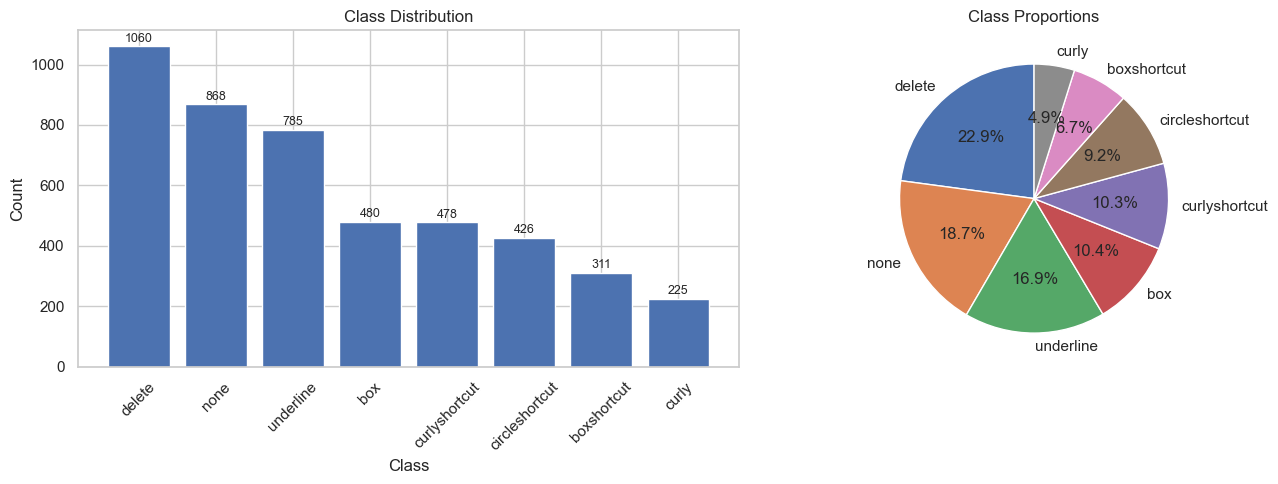

In [35]:
# Class distribution
class_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — NO explicit colors
bars = axes[0].bar(class_counts.index, class_counts.values)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
axes[0].tick_params(axis='x', rotation=45)

# Add count labels
for bar, count in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Pie chart — inherit same color cycle automatically
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()


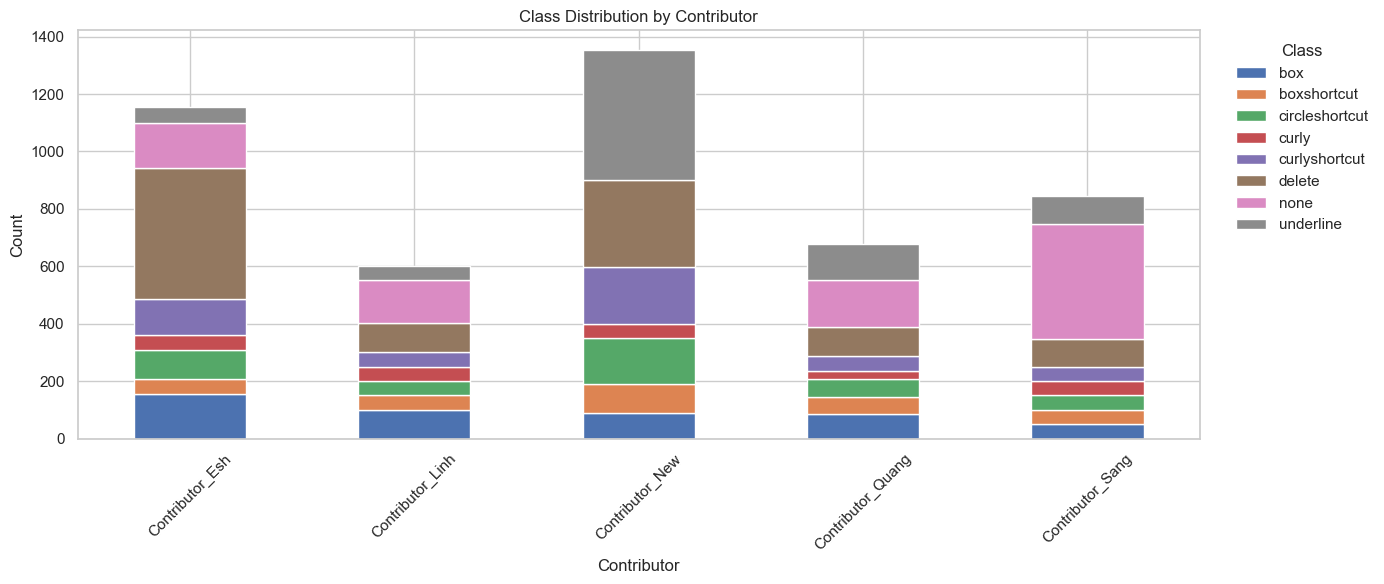

In [39]:
# Distribution by contributor
contrib_class = pd.crosstab(df['contributor'], df['type'])

fig, ax = plt.subplots(figsize=(14, 6))
contrib_class.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Contributor')
ax.set_ylabel('Count')
ax.set_title('Class Distribution by Contributor')
ax.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Stroke Visualization

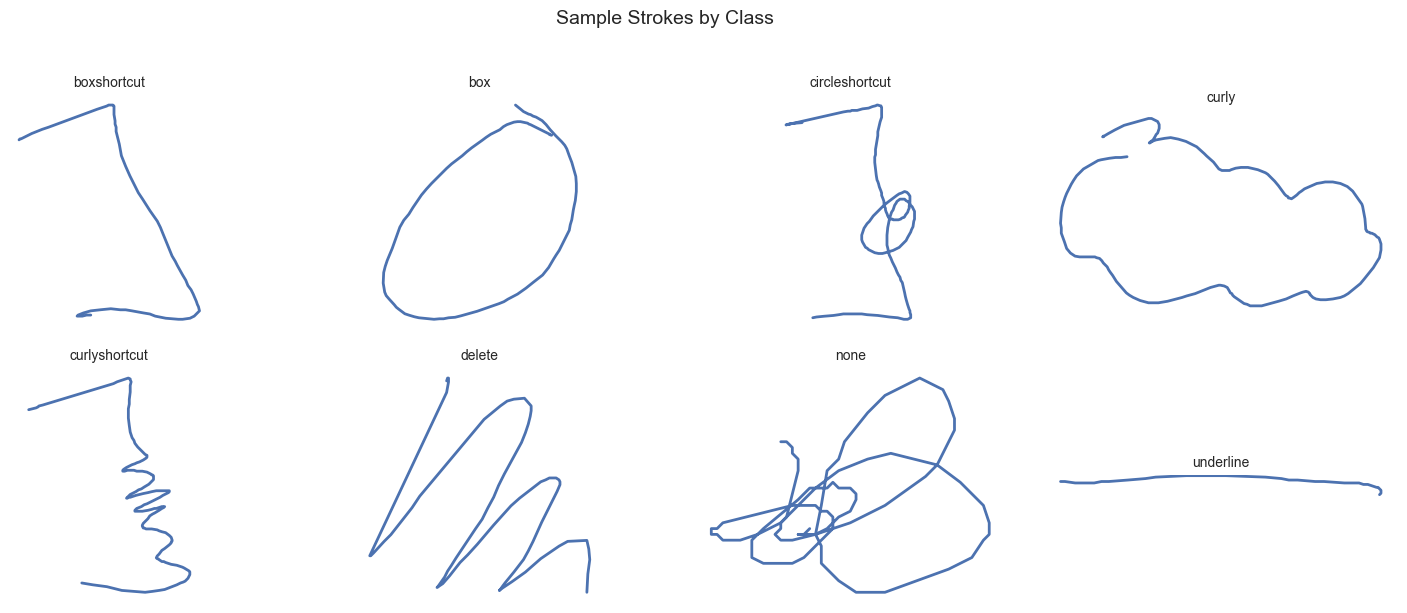

In [43]:
def plot_stroke(stroke, ax, title=''):
    """Plot a single stroke."""
    x = [p['x'] for p in stroke]
    y = [p['y'] for p in stroke]
    ax.plot(x, y, linewidth=2)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Get unique classes
classes = df['type'].unique()
n_classes = len(classes)

# Plot samples from each class
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    sample = df[df['type'] == cls].iloc[0]
    plot_stroke(sample['stroke'], axes[idx], title=cls)

plt.suptitle('Sample Strokes by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Stroke visualization per file (to check for possibility of false labeling)

In [44]:
file_modifiers = load_json_file(r"C:\Users\huybh\onedrive\documents\onepen\data\raw\Contributor_Esh\curlyshortcut_1.json")
single_data = []

for mod in file_modifiers: 
    stroke = mod.get("stroke", [])

    if len(stroke) < 2:
        continue

    # Get class name from the 'type' field inside the JSON
    class_name = mod.get("type")
    if class_name is None:
        continue

    class_name = class_name.strip().lower()
    
    single_data.append({
        "type": class_name,
        "stroke": stroke,
    })



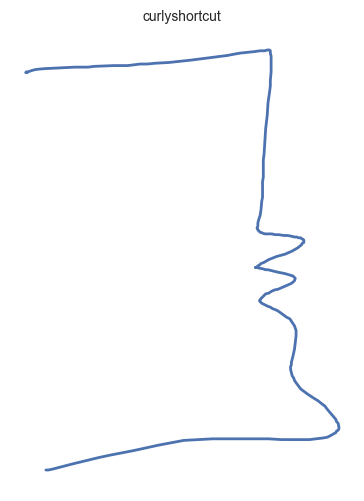

In [46]:
single_df = pd.DataFrame(single_data)
sample = single_df.iloc[0]

fig, axe = plt.subplots(1, 1, figsize=(15, 6))

plot_stroke(sample['stroke'], axe, title=sample['type'])

### Visualize multiple RANDOM samples per class (to see variation)

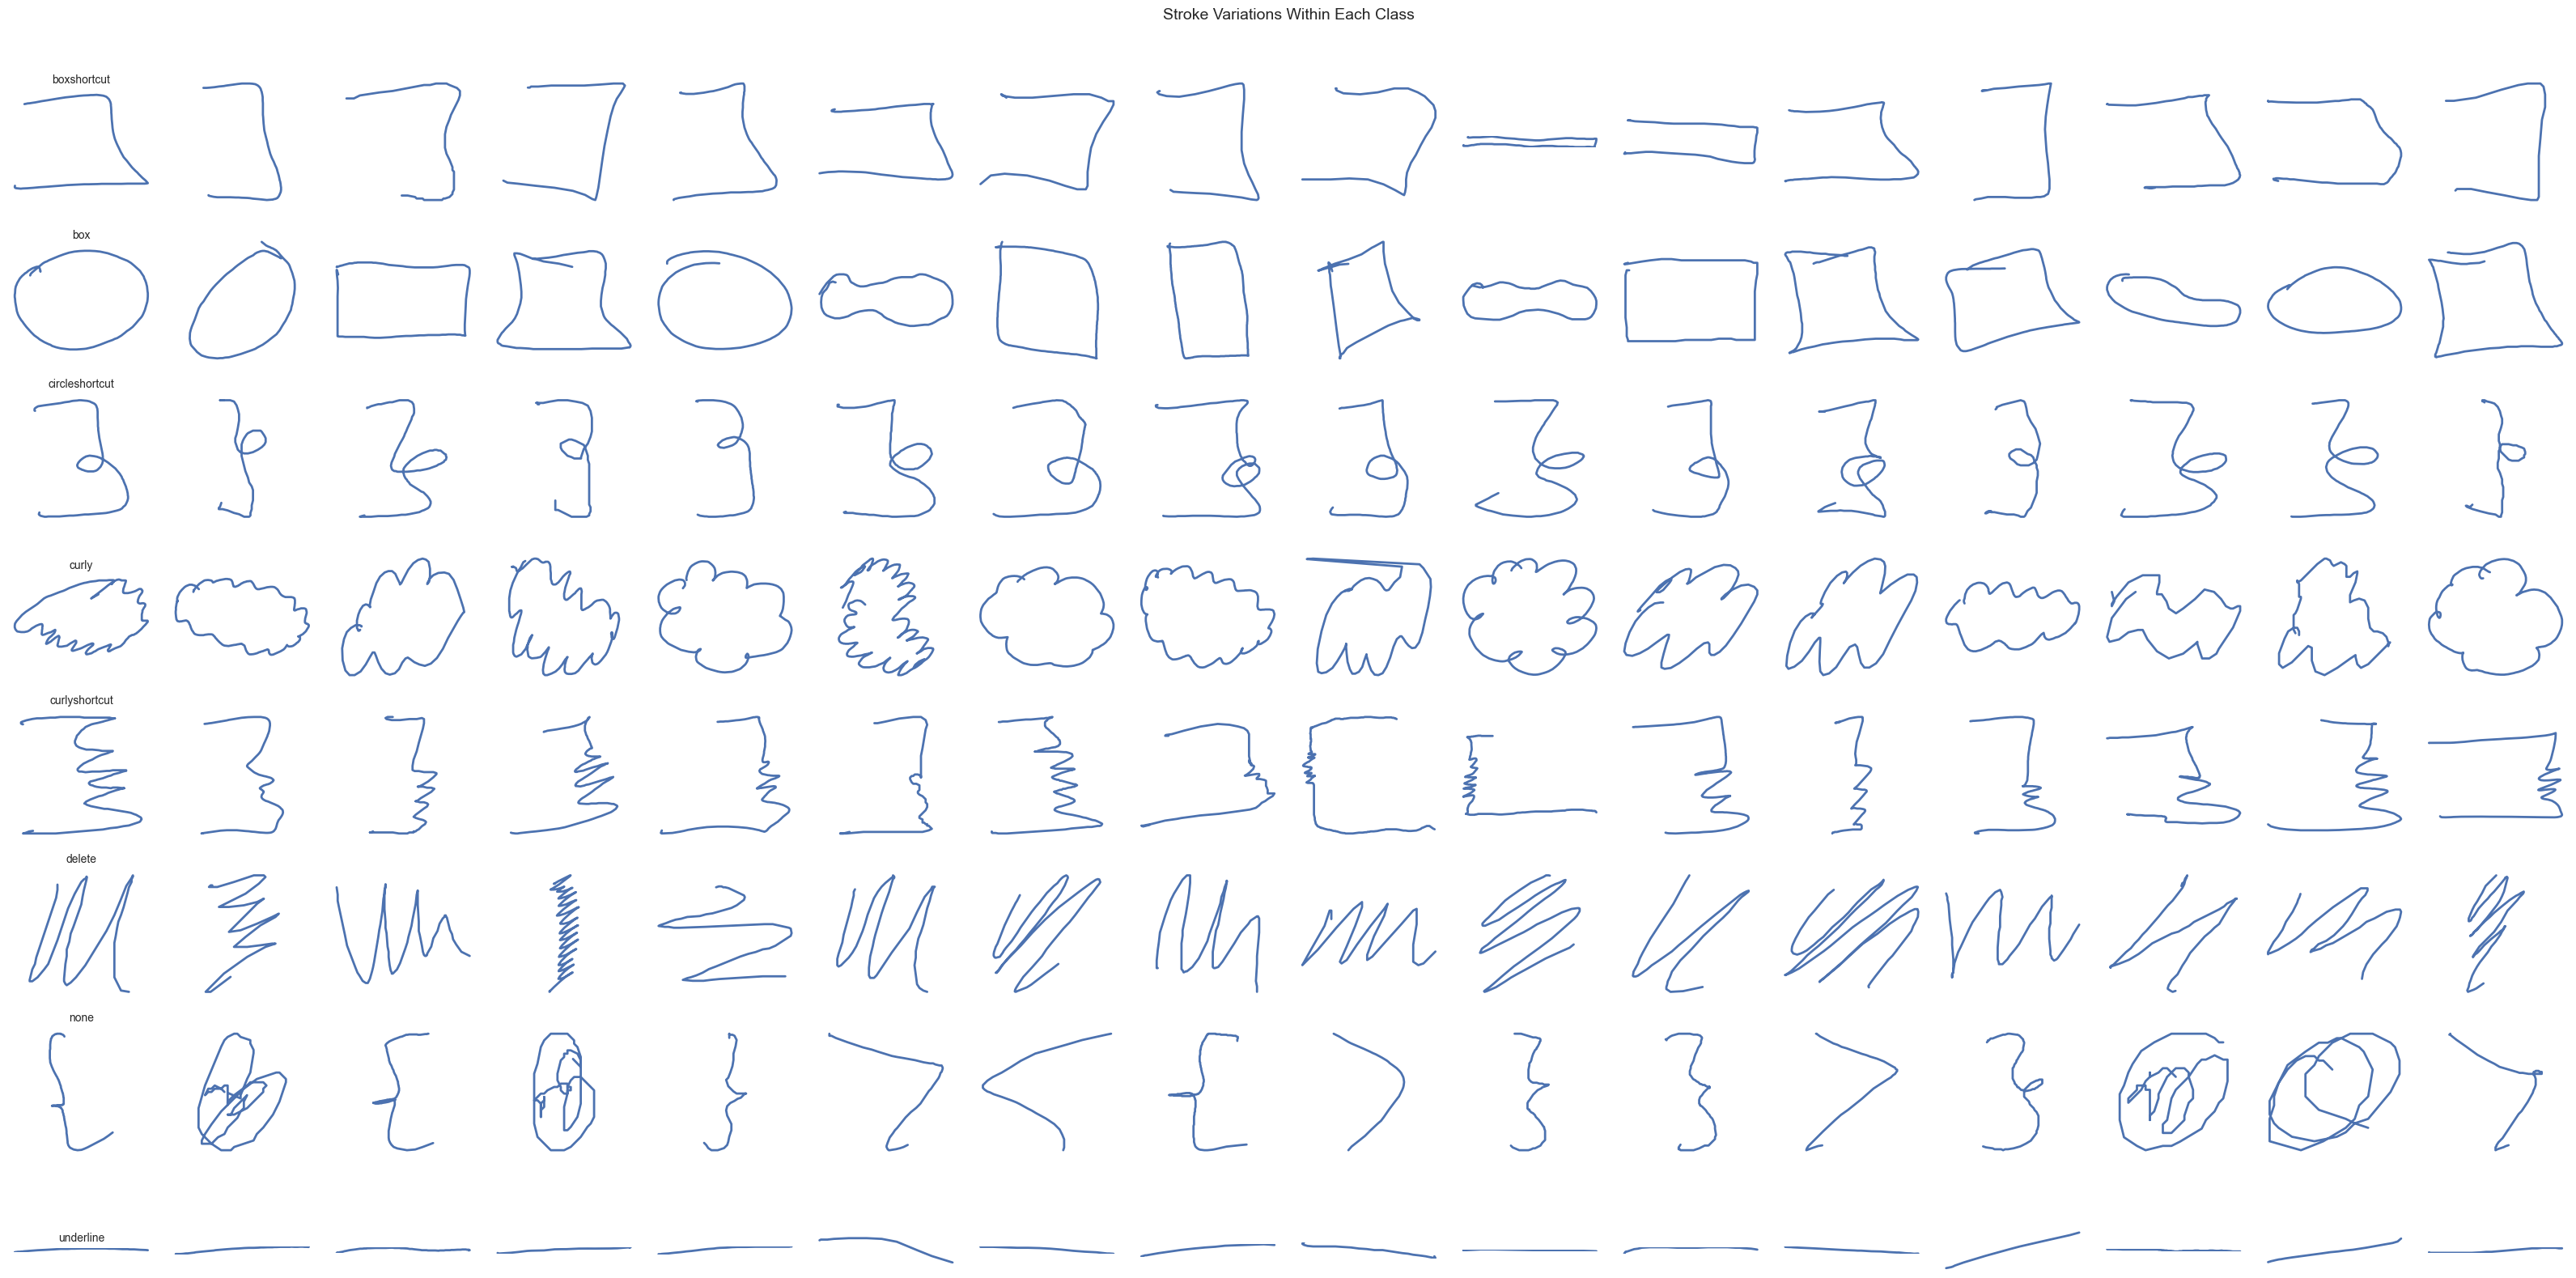

In [47]:
n_samples = 16

fig, axes = plt.subplots(len(classes), n_samples, figsize=(2 * n_samples, len(classes) * 2))

for row, cls in enumerate(classes):
    # Randomly sample 16 strokes from each class
    samples = (
        df[df['type'] == cls]
        .sample(n=min(n_samples, len(df[df['type'] == cls])), random_state=None)
    )

    for col, (_, sample) in enumerate(samples.iterrows()):
        plot_stroke(
            sample['stroke'],
            axes[row, col],
            title=cls if col == 0 else ''
        )

# Clean up any empty axes (if class has < 16 samples)
for ax in axes.flat:
    ax.axis("off")

plt.suptitle('Stroke Variations Within Each Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


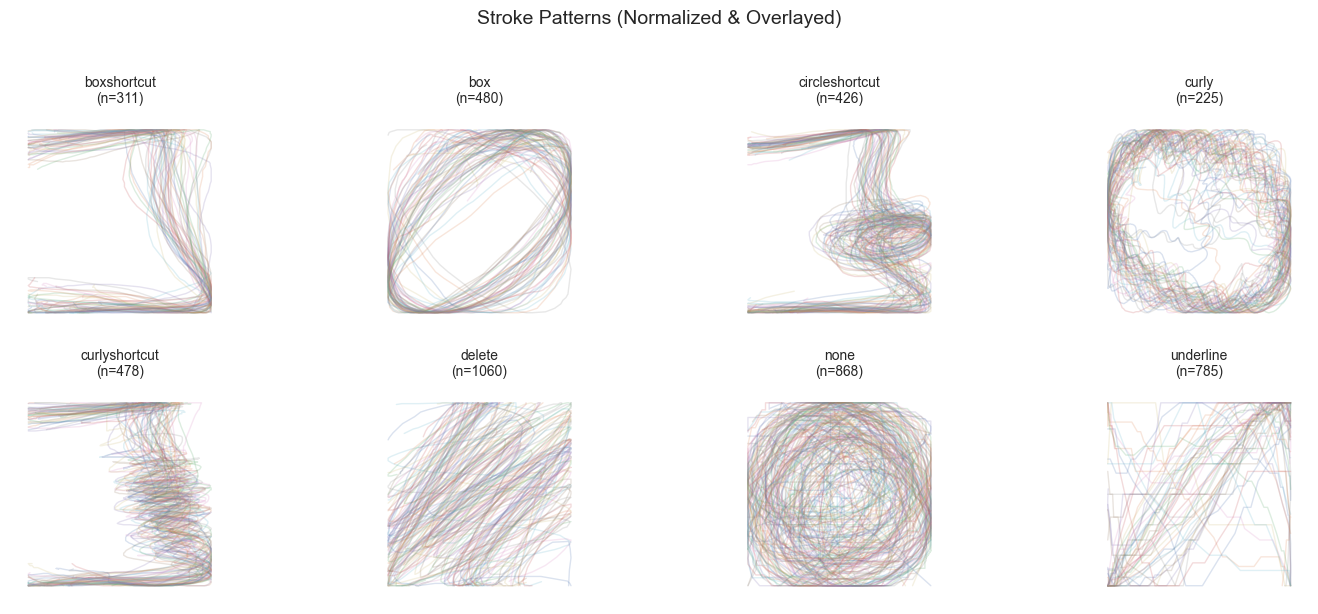

In [49]:
# Overlay all strokes per class (normalized)
def normalize_stroke(stroke):
    x = np.array([p['x'] for p in stroke])
    y = np.array([p['y'] for p in stroke])
    
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    w = max(x_max - x_min, 1e-6)
    h = max(y_max - y_min, 1e-6)
    
    return (x - x_min) / w, (y - y_min) / h

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    class_strokes = df[df['type'] == cls]['stroke'].values
    
    for stroke in class_strokes[:50]:  # Limit for clarity
        x_norm, y_norm = normalize_stroke(stroke)
        axes[idx].plot(x_norm, y_norm, alpha=0.2, linewidth=1)
    
    axes[idx].invert_yaxis()
    axes[idx].set_xlim(-0.1, 1.1)
    axes[idx].set_ylim(1.1, -0.1)
    axes[idx].set_aspect('equal')
    axes[idx].set_title(f'{cls}\n(n={len(class_strokes)})', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Stroke Patterns (Normalized & Overlayed)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Geometric Feature Analysis

This section explores geometric features that could be useful for stroke classification. 

**Candidate Features:**
- **Shape features:** aspect ratio, compactness, direction bias
- **Size features:** width, height, total length, diagonal
- **Complexity features:** curvature, rectilinearity, point density
- **Position features:** edge fraction, spine verticality, closure ratio
- **Statistical features:** variance in x/y coordinates



In [50]:
def compute_all_geometric_features(stroke, height_threshold=45, cap_value=100):
    if len(stroke) < 2:
        return None
    
    # Extract coordinates
    pts = np.array([[p['x'], p['y']] for p in stroke])
    x, y = pts[:, 0], pts[:, 1]
    n_points = len(pts)
    
    # Bounding box
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    # Use 1.0 as min dimension to avoid division by zero stability issues for dots/lines
    width = max(x_max - x_min, 1.0)
    height = max(y_max - y_min, 1.0)
    bbox_area = width * height
    diag = np.sqrt(width**2 + height**2)
    
    # Segment calculations
    deltas = np.diff(pts, axis=0)
    seg_lengths = np.linalg.norm(deltas, axis=1)
    total_len = np.sum(seg_lengths)
    
    # Normalized coordinates
    x_norm = (x - x_min) / width
    y_norm = (y - y_min) / height
    
    # ============== SHAPE FEATURES ==============
    
    # Perimeter to diagonal ratio
    perim_diag_ratio = (2 * (width + height)) / (diag + 1e-6)
    
    # Direction bias: |w-h|/(w+h) - bounded [0,1], 0=square, 1=line
    direction_bias = abs(width - height) / (width + height + 1e-6)
    
    # Aspect ratio bounded using atan: 2*atan(w/h)/pi - bounded [0,1], 0.5=square
    aspect_ratio = 2 * np.arctan(width / height) / np.pi
    
    # Compactness: path length / diagonal (how "squiggly" is the stroke)
    compactness = total_len / (diag + 1e-6)
    
    # ============== SIZE FEATURES ==============
    
    # Raw dimensions (will need normalization for model)
    raw_width = width
    raw_height = height
    raw_total_len = total_len
    
    # Height difference from threshold (normalized)
    height_diff = np.clip((height - height_threshold) / cap_value, -1.0, 1.0)
    
    # ============== COMPLEXITY FEATURES ==============
    
    # Average curvature (angle change between segments)
    avg_curvature = 0.0
    max_curvature = 0.0
    if len(deltas) > 1:
        angles = np.arctan2(deltas[:, 1], deltas[:, 0])
        # Robust angle difference handling wraparound
        raw_diffs = np.diff(angles)
        angle_diffs = (raw_diffs + np.pi) % (2 * np.pi) - np.pi
        abs_diffs = np.abs(angle_diffs)
        avg_curvature = np.mean(abs_diffs)
        max_curvature = np.max(abs_diffs)
    
    # Rectilinearity: fraction of ~straight or ~90° segments
    rectilinearity = 0.0
    if len(deltas) > 1:
        angles = np.arctan2(deltas[:, 1], deltas[:, 0])
        raw_diffs = np.diff(angles)
        # Normalize to [-pi, pi]
        angle_diffs = (raw_diffs + np.pi) % (2 * np.pi) - np.pi
        abs_diffs = np.abs(angle_diffs)
        # Check if segment turn is near 0 OR near 90 degrees (pi/2)
        # Tolerance 0.2 rad is approx 11 degrees
        is_straight = abs_diffs < 0.2
        is_right_angle = np.abs(abs_diffs - np.pi / 2) < 0.2
        rect_count = np.sum(is_straight | is_right_angle)
        rectilinearity = rect_count / len(angle_diffs)
    
    # Point density (log scale)
    # Use max(area, 1.0) to avoid explosion for dots/lines
    density = n_points / bbox_area
    log_density = np.log1p(density)
    
    # Points per unit length
    # Use max(len, 1.0) to avoid explosion for zero-length strokes
    points_per_length = n_points / max(total_len, 1.0)
    
    # ============== POSITION FEATURES ==============
    
    # Edge fraction: how many points are near the bounding box edges
    edge_thresh = 0.1
    d_edge = np.minimum.reduce([x_norm, 1 - x_norm, y_norm, 1 - y_norm])
    edge_frac = np.mean(d_edge < edge_thresh)
    
    # Spine verticality: how vertical is start-to-end direction (0=horizontal, 1=vertical)
    dx_spine = x[-1] - x[0]
    dy_spine = y[-1] - y[0]
    spine_angle = abs(np.arctan2(dy_spine, dx_spine))
    spine_verticality = 1 - abs(spine_angle - np.pi / 2) / (np.pi / 2)
    
    # Overall direction in degrees
    direction_deg = np.arctan2(dy_spine, dx_spine) * 180 / np.pi
    
    # Closure ratio: how close is end to start (1=closed loop, 0=open)
    end_to_start = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)
    closure_ratio = 1 - min(end_to_start / (diag + 1e-6), 1.0)
    
    # ============== STATISTICAL FEATURES ==============
    
    # Variance in coordinates
    horiz_var = np.std(x)
    vert_var = np.std(y)
    
    # Center of mass position (normalized)
    center_x = np.mean(x_norm)
    center_y = np.mean(y_norm)
    
    # Spread ratio (how spread out vs concentrated)
    spread = np.std(np.linalg.norm(pts - pts.mean(axis=0), axis=1))
    spread_ratio = spread / (diag + 1e-6)
    
    return {
        # Shape features
        'perim_diag_ratio': perim_diag_ratio,
        'direction_bias': direction_bias,
        'aspect_ratio': aspect_ratio,
        'compactness': compactness,
        # Size features
        'width': raw_width,
        'height': raw_height,
        'total_len': total_len,
        'height_diff': height_diff,
        # Complexity features
        'avg_curvature': avg_curvature,
        'max_curvature': max_curvature,
        'rectilinearity': rectilinearity,
        'log_density': log_density,
        'points_per_length': points_per_length,
        # Position features
        'edge_frac': edge_frac,
        'spine_verticality': spine_verticality,
        'direction_deg': direction_deg,
        'closure_ratio': closure_ratio,
        # Statistical features
        'horiz_var': horiz_var,
        'vert_var': vert_var,
        'center_x': center_x,
        'center_y': center_y,
        'spread_ratio': spread_ratio,
        # Meta
        'num_points': n_points,
    }

# Compute features for all strokes
features_list = []
for _, row in df.iterrows():
    feats = compute_all_geometric_features(row['stroke'])
    if feats:
        feats['type'] = row['type']
        feats['contributor'] = row['contributor']
        features_list.append(feats)

features_df = pd.DataFrame(features_list)

# All numeric features for analysis
all_features = [col for col in features_df.columns if col not in ['type', 'contributor']]

features_df[features_df['type'] == 'delete'].head()

,perim_diag_ratio,direction_bias,aspect_ratio,compactness,width,height,total_len,height_diff,avg_curvature,max_curvature,...,direction_deg,closure_ratio,horiz_var,vert_var,center_x,center_y,spread_ratio,num_points,type,contributor
485,2.828178,0.013274,0.508450,3.558406,107.009308,104.205612,531.500179,0.592056,0.329742,3.141593,...,56.430318,0.173953,27.399550,32.752463,0.569301,0.608145,0.110230,73,delete,Contributor_Esh
486,2.793938,0.157609,0.400482,3.389655,72.429840,99.532700,417.255973,0.545327,0.254864,2.356227,...,87.534247,0.205877,20.687632,28.536844,0.401129,0.494308,0.100509,80,delete,Contributor_Esh
487,2.822866,0.062802,0.539928,3.584252,102.803680,90.654205,491.275056,0.456542,0.253873,3.141593,...,45.228311,0.394907,25.527417,26.257409,0.472004,0.585754,0.090489,88,delete,Contributor_Esh
488,2.827578,0.024510,0.515600,3.303312,97.663544,92.990639,445.462670,0.479906,0.231013,2.356186,...,85.403199,0.308206,27.145153,23.684137,0.464438,0.457626,0.094989,74,delete,Contributor_Esh
489,2.827793,0.021176,0.513479,3.200622,101.401855,97.196259,449.564319,0.521963,0.268007,3.141593,...,97.125019,0.302637,28.276197,23.735785,0.505469,0.527050,0.099946,83,delete,Contributor_Esh


In [101]:
# Feature statistics overview
print("=" * 80)
print("FEATURE STATISTICS SUMMARY")
print("=" * 80)
print(features_df[all_features].describe().round(4))

# Check for any problematic values
print("\n" + "=" * 80)
print("DATA QUALITY CHECK")
print("=" * 80)
print(f"\nMissing values: {features_df[all_features].isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(features_df[all_features].values).sum()}")

# Check value ranges
print("\nFeature value ranges:")
for feat in all_features:
    min_val = features_df[feat].min()
    max_val = features_df[feat].max()
    bounded = "bounded" if (min_val >= -10 and max_val <= 1000) else "UNBOUNDED - may need scaling"
    print(f"  {feat:20s}: [{min_val:10.2f}, {max_val:10.2f}] - {bounded}")

FEATURE STATISTICS SUMMARY
       perim_diag_ratio  direction_bias  aspect_ratio  compactness      width  \
count         3279.0000       3279.0000     3279.0000    3279.0000  3279.0000   
mean             2.6752          0.2848        0.5381       2.6936   121.1879   
std              0.2107          0.2509        0.2090       1.5600   111.8377   
min              2.0130          0.0000        0.0677       0.3508     1.0000   
25%              2.6353          0.0943        0.3876       1.7096    41.5889   
50%              2.7648          0.2157        0.5141       2.3459    85.0000   
75%              2.8159          0.3898        0.6645       3.0639   165.0000   
max              2.8284          0.9871        0.9959      12.9695   970.0934   

          height  total_len  height_diff  avg_curvature  max_curvature  ...  \
count  3279.0000  3279.0000    3279.0000      3279.0000      3279.0000  ...   
mean     95.9821   410.1765       0.3361         0.5912         2.4403  ...   
std   

C:\Users\huybh\AppData\Local\Temp\ipykernel_19528\1810131113.py:17: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

C:\Users\huybh\AppData\Local\Temp\ipykernel_19528\1810131113.py:17: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

C:\Users\huybh\AppData\Local\Temp\ipykernel_19528\1810131113.py:17: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

C:\Users\huybh\AppData\Local\Temp\ipykernel_19528\1810131113.py:17: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

C:\Users\huybh\AppData\Local\Temp\ipykernel_

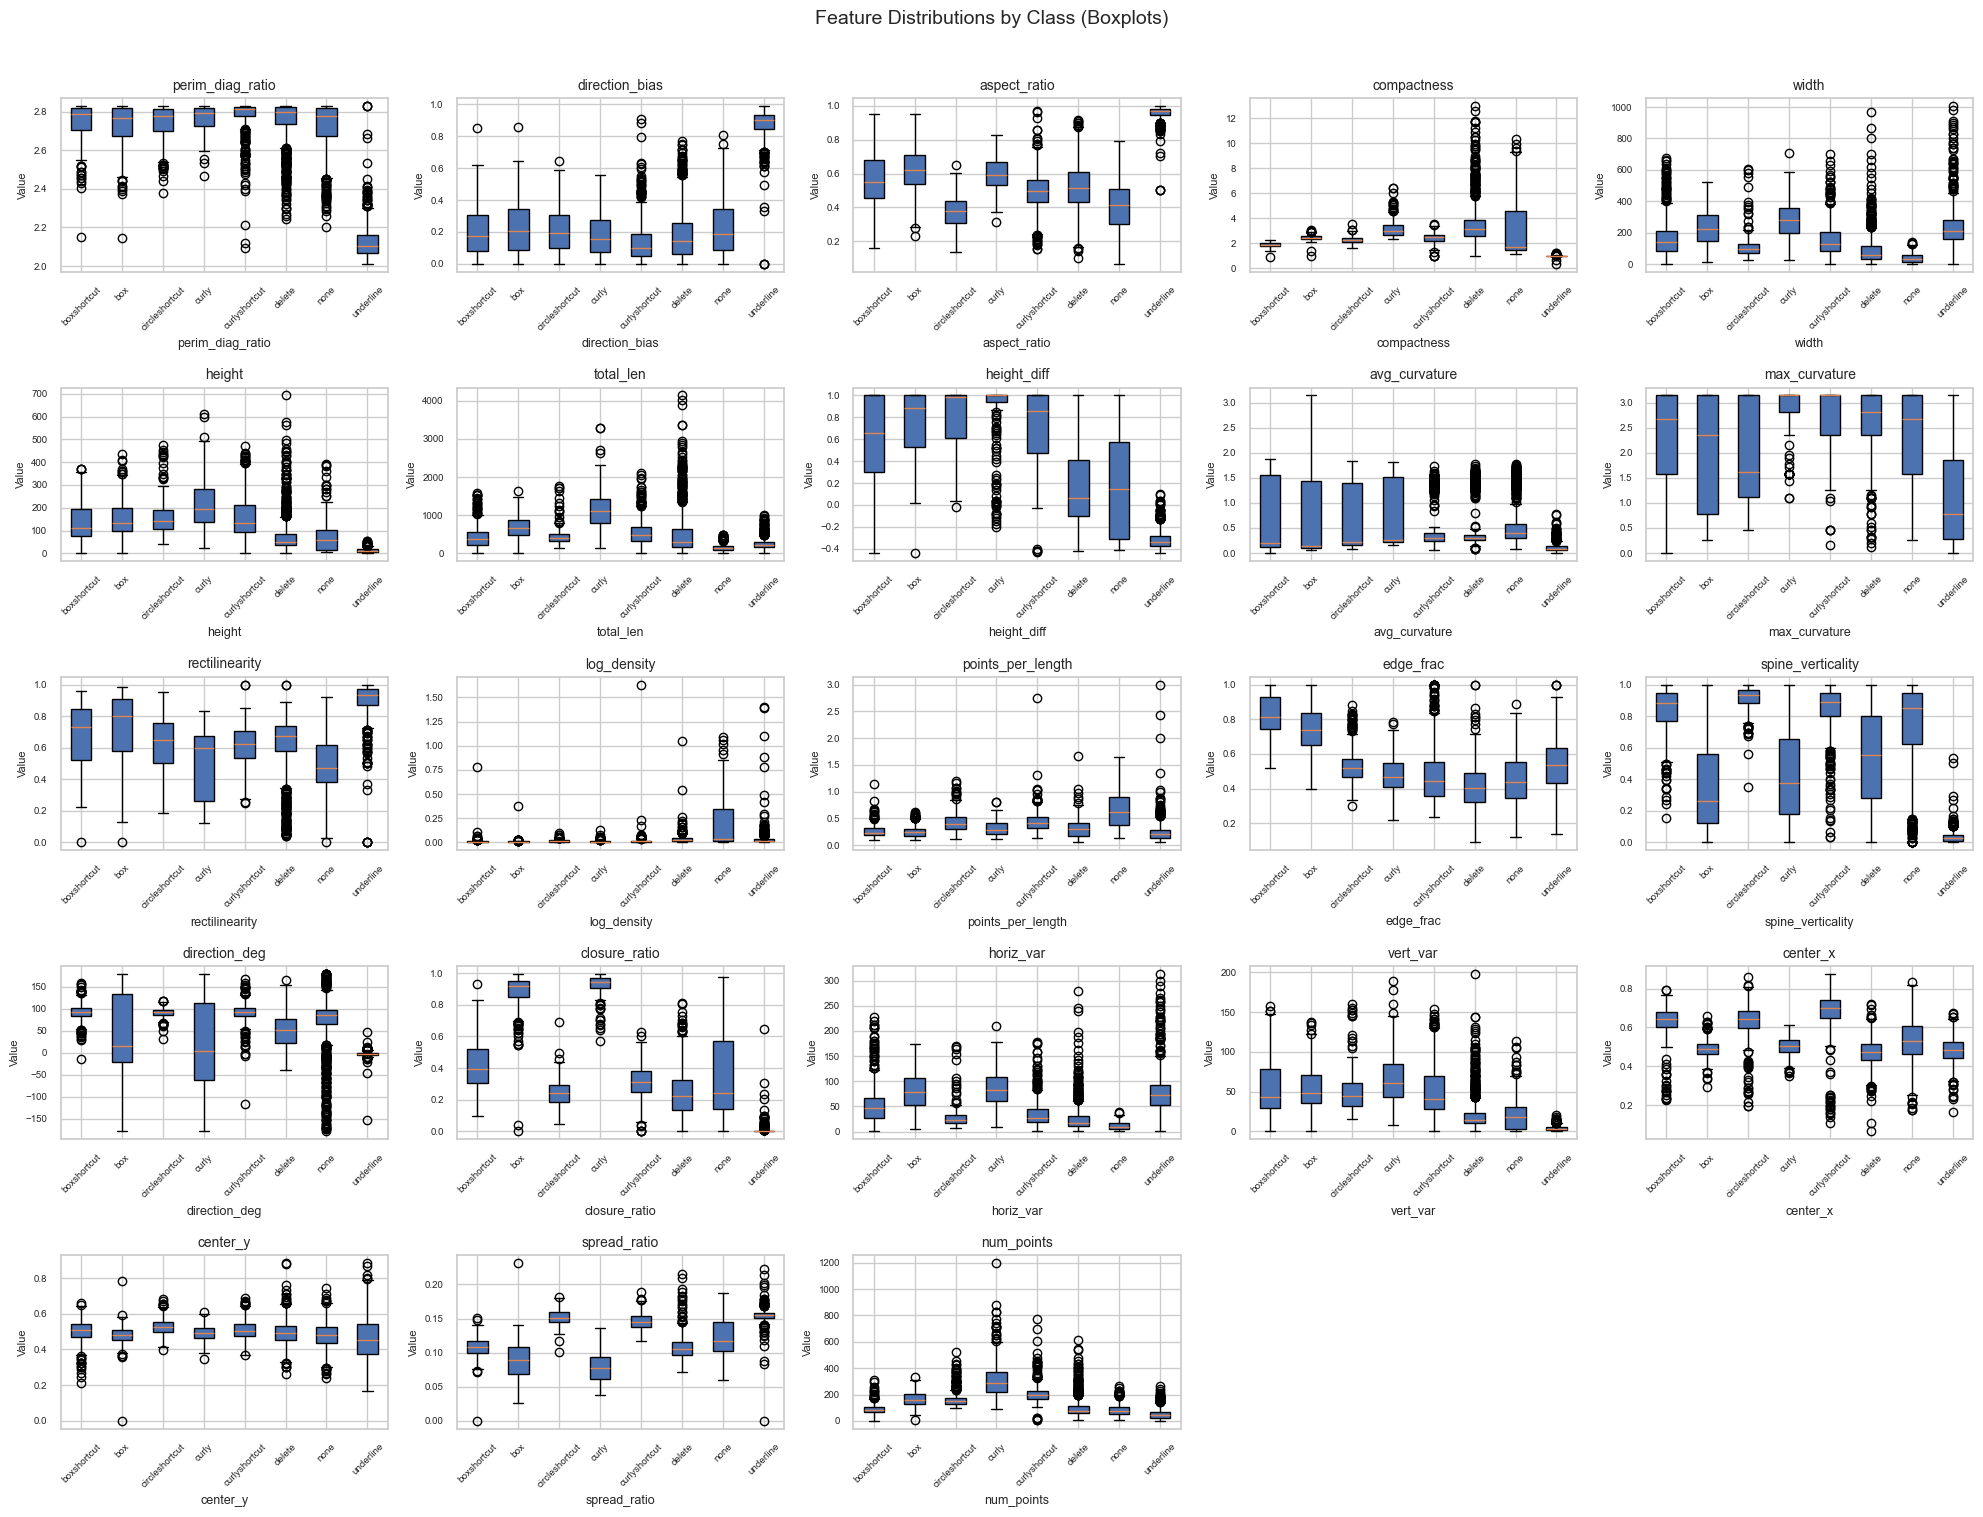

In [51]:
# Feature distributions by class — BOXPLOTS
n_features = len(all_features)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for idx, feat in enumerate(all_features):
    ax = axes[idx]

    data = [
        features_df[features_df['type'] == cls][feat]
        for cls in classes
    ]

    ax.boxplot(
        data,
        labels=classes,
        patch_artist=True
    )

    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Value', fontsize=8)
    ax.set_title(feat, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Hide unused subplots
for idx in range(len(all_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Feature Distributions by Class (Boxplots)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


perim_diag_ratio, direction_bias, aspect_ratio, height_diff, avg_culvature, max_curvature, rectilinearity, spine_verticality, edge_frac, direction_deg can be used since their distribution is relatively distinctive by class

## 6. Correlation Analysis

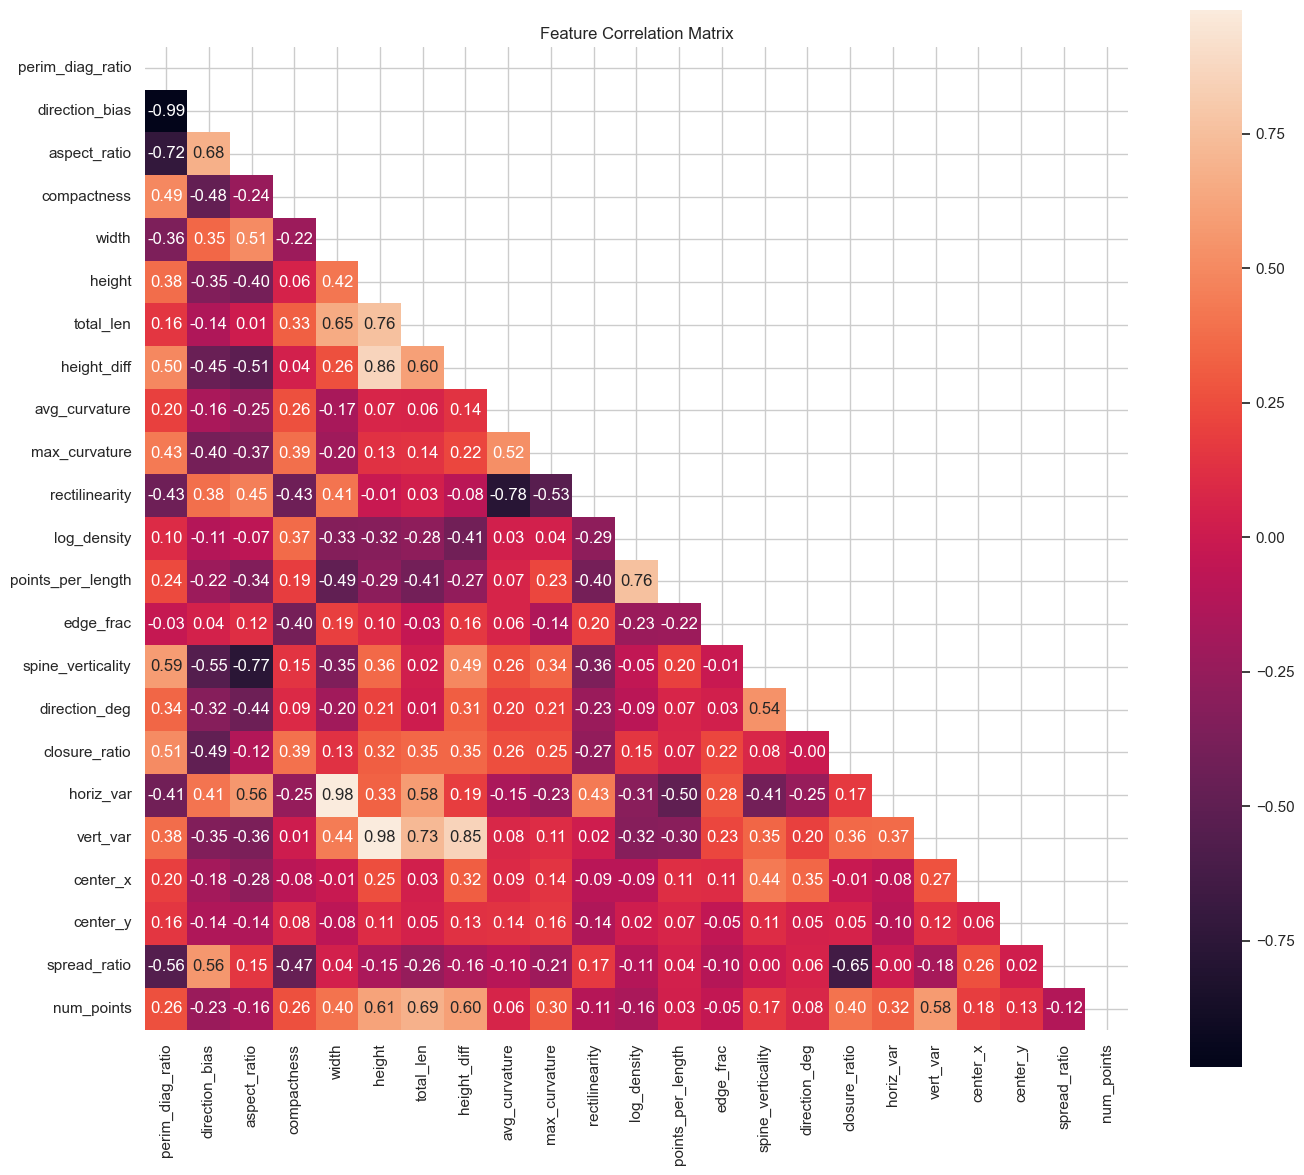

In [52]:
# Feature correlation matrix
corr_matrix = features_df[all_features].corr()

plt.figure(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 7. Feature Selection: Choosing the Best Features

ANOVA F-TEST: FEATURE DISCRIMINATIVE POWER
Higher F-score = better class separation
  perim_diag_ratio      : F=  3543.7 ██████████████████████████████ ***
  closure_ratio         : F=  2050.7 ██████████████████████████████ ***
  direction_bias        : F=  2025.3 ██████████████████████████████ ***
  aspect_ratio          : F=  1640.7 ██████████████████████████████ ***
  spread_ratio          : F=  1181.7 ██████████████████████████████ ***
  spine_verticality     : F=  1021.0 ██████████████████████████████ ***
  height_diff           : F=   856.4 ██████████████████████████████ ***
  num_points            : F=   635.0 ██████████████████████████████ ***
  edge_frac             : F=   581.6 ██████████████████████████████ ***
  horiz_var             : F=   543.2 ██████████████████████████████ ***
  vert_var              : F=   532.1 ██████████████████████████████ ***
  center_x              : F=   479.0 ██████████████████████████████ ***
  height                : F=   439.0 ███████████████

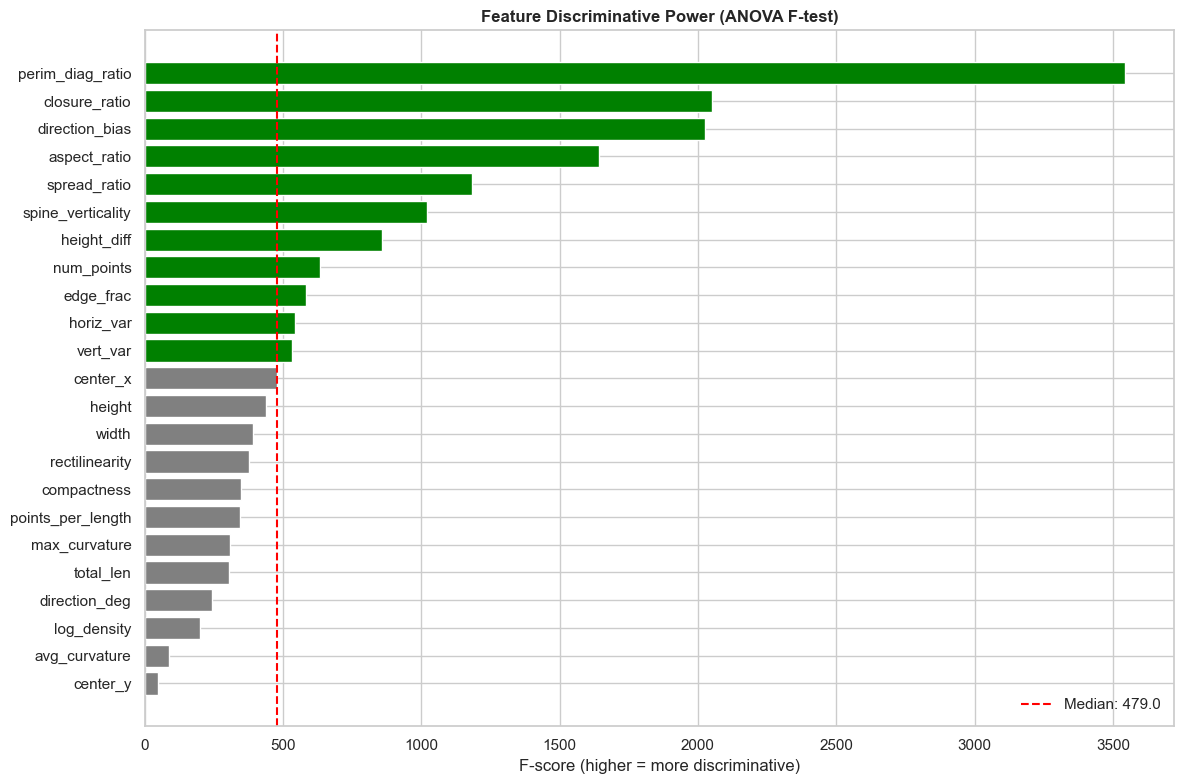

In [53]:
# ANOVA F-test for all features
from scipy.stats import f_oneway

f_scores = {}
for feat in all_features:
    groups = [features_df[features_df['type'] == cls][feat].dropna().values for cls in classes]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        f_scores[feat] = {'F-score': f_stat, 'p-value': p_val}

f_df = pd.DataFrame(f_scores).T.sort_values('F-score', ascending=False)

print("=" * 70)
print("ANOVA F-TEST: FEATURE DISCRIMINATIVE POWER")
print("Higher F-score = better class separation")
print("=" * 70)

for feat in f_df.index:
    f_val = f_df.loc[feat, 'F-score']
    p_val = f_df.loc[feat, 'p-value']
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    bar = "█" * min(int(f_val / 10), 30)
    print(f"  {feat:22s}: F={f_val:8.1f} {bar} {sig}")

# Visualize
plt.figure(figsize=(12, 8))
f_sorted = f_df.sort_values('F-score', ascending=True)
colors_bar = ['green' if f > f_df['F-score'].median() else 'gray' for f in f_sorted['F-score']]
plt.barh(f_sorted.index, f_sorted['F-score'], color=colors_bar)
plt.axvline(x=f_df['F-score'].median(), color='red', linestyle='--', label=f'Median: {f_df["F-score"].median():.1f}')
plt.xlabel('F-score (higher = more discriminative)')
plt.title('Feature Discriminative Power (ANOVA F-test)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

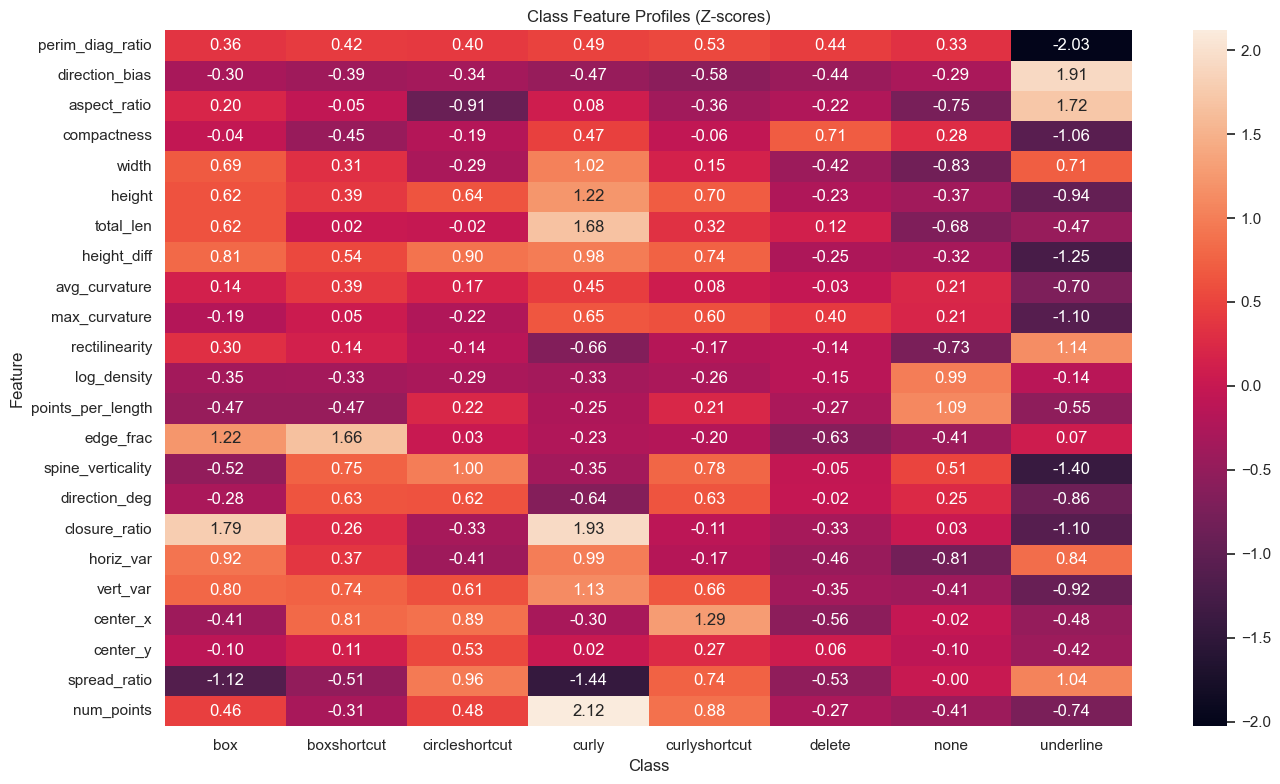

In [54]:
# Per-class feature profiles
class_means = features_df.groupby('type')[all_features].mean()
global_means = features_df[all_features].mean()
global_stds = features_df[all_features].std()

# Standardized class profiles (z-scores)
class_z_scores = (class_means - global_means) / (global_stds + 1e-6)

# Heatmap (minimal)
plt.figure(figsize=(14, 8))

sns.heatmap(
    class_z_scores.T,
    annot=True,
    fmt=".2f"
)

plt.title("Class Feature Profiles (Z-scores)")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


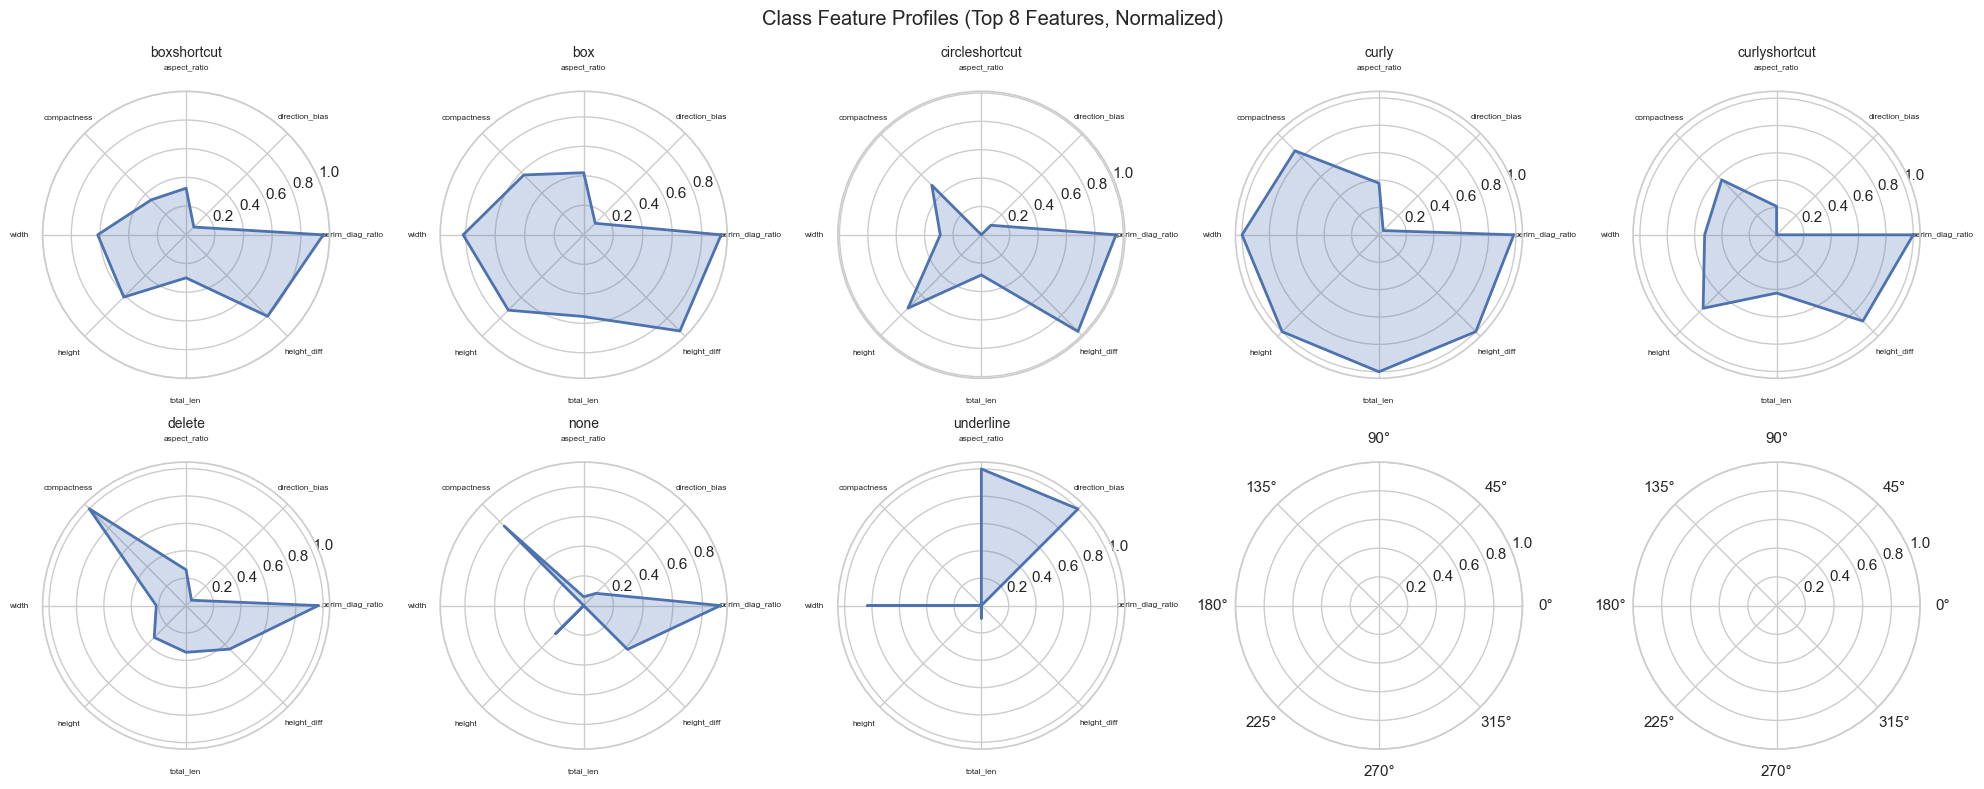

In [57]:
from math import pi

def make_radar_chart(ax, class_name, values, feature_names):
    """Create a minimal radar chart using default color cycle."""
    N = len(feature_names)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    values_plot = values.tolist()
    values_plot += values_plot[:1]

    ax.plot(angles, values_plot, linewidth=2)
    ax.fill(angles, values_plot, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_names, size=6)
    ax.set_title(class_name, size=10)

radar_features = (
    combined_df.head(8)['feature'].tolist()
    if 'combined_df' in dir()
    else all_features[:8]
)

fig, axes = plt.subplots(
    2, 5,
    figsize=(20, 8),
    subplot_kw=dict(projection='polar')
)
axes = axes.flatten()

for idx, cls in enumerate(classes):
    make_radar_chart(
        axes[idx],
        cls,
        class_means_norm.loc[cls],
        radar_features
    )

plt.suptitle("Class Feature Profiles (Top 8 Features, Normalized)")
plt.tight_layout()
plt.show()



In [58]:
# COMPREHENSIVE FEATURE SELECTION ANALYSIS
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

# Prepare data
X = features_df[all_features].values
y_labels = features_df['type'].values
le = LabelEncoder()
y = le.fit_transform(y_labels)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=" * 80)
print("FEATURE SELECTION ANALYSIS")
print("=" * 80)

# ============== METHOD 1: ANOVA F-Score ==============
print("\n1. ANOVA F-SCORE (linear class separation)")
selector_anova = SelectKBest(f_classif, k='all')
selector_anova.fit(X_scaled, y)
anova_scores = pd.DataFrame({
    'feature': all_features,
    'anova_score': selector_anova.scores_
}).sort_values('anova_score', ascending=False)

# ============== METHOD 2: Mutual Information ==============
print("2. MUTUAL INFORMATION (non-linear dependencies)")
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': all_features,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

# ============== METHOD 3: Random Forest Importance ==============
print("3. RANDOM FOREST IMPORTANCE (feature interactions)")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)
rf_df = pd.DataFrame({
    'feature': all_features,
    'rf_importance': rf.feature_importances_
}).sort_values('rf_importance', ascending=False)

# ============== METHOD 4: Recursive Feature Elimination ==============
print("4. RECURSIVE FEATURE ELIMINATION (wrapper method)")
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(lr, n_features_to_select=10, step=1)
rfe.fit(X_scaled, y)
rfe_df = pd.DataFrame({
    'feature': all_features,
    'rfe_rank': rfe.ranking_,
    'rfe_selected': rfe.support_
})

# ============== COMBINE ALL METHODS ==============
combined_df = pd.merge(anova_scores, mi_df, on='feature')
combined_df = pd.merge(combined_df, rf_df, on='feature')
combined_df = pd.merge(combined_df, rfe_df, on='feature')

# Normalize scores to 0-1 range for comparison
for col in ['anova_score', 'mi_score', 'rf_importance']:
    combined_df[f'{col}_norm'] = (combined_df[col] - combined_df[col].min()) / (combined_df[col].max() - combined_df[col].min() + 1e-6)

# Compute combined score (average of normalized scores)
combined_df['combined_score'] = (
    combined_df['anova_score_norm'] + 
    combined_df['mi_score_norm'] + 
    combined_df['rf_importance_norm']
) / 3

# Add RFE bonus for selected features
combined_df['combined_score'] += combined_df['rfe_selected'].astype(float) * 0.1

combined_df = combined_df.sort_values('combined_score', ascending=False)

print("\n" + "=" * 80)
print("FEATURE RANKING (Combined Score)")
print("=" * 80)
print(combined_df[['feature', 'anova_score', 'mi_score', 'rf_importance', 'rfe_selected', 'combined_score']].to_string(index=False))

FEATURE SELECTION ANALYSIS

1. ANOVA F-SCORE (linear class separation)
2. MUTUAL INFORMATION (non-linear dependencies)
3. RANDOM FOREST IMPORTANCE (feature interactions)
4. RECURSIVE FEATURE ELIMINATION (wrapper method)

FEATURE RANKING (Combined Score)
          feature  anova_score  mi_score  rf_importance  rfe_selected  combined_score
      compactness   349.559557  0.989984       0.133063          True        0.795358
    closure_ratio  2050.712914  0.864629       0.089461          True        0.791615
     aspect_ratio  1640.747240  0.606040       0.071174          True        0.601864
     spread_ratio  1181.652356  0.655433       0.076998          True        0.593091
 perim_diag_ratio  3543.735887  0.457364       0.034348         False        0.526327
         vert_var   532.111479  0.618764       0.043983          True        0.428369
       num_points   635.016004  0.502943       0.055766          True        0.424158
   direction_bias  2025.272343  0.456624       0.039501   

In [59]:
# Check strokes with very few points
point_threshold = 5
short_strokes = df[df['num_points'] < point_threshold]
print(f"\nStrokes with < {point_threshold} points: {len(short_strokes)}")

if len(short_strokes) > 0:
    print("Distribution by class:")
    print(short_strokes['type'].value_counts())


Strokes with < 5 points: 5
Distribution by class:
type
underline      3
delete         1
boxshortcut    1
Name: count, dtype: int64


## 9. Key Insights & Recommendations

During previous training a model without features engineering, there are a few classes that have siginficant amount of misclassify between each other:
- underline vs delete
- The shortcut groups
- Box vs shortcut
- Curly vs curlyshortcut 

#### Trial 1 note:
Going with 10 features: (closure_ratio, compactness, spread_ratio, edge_frac, num_points_feat, height_diff, horiz_var, total_len, perim_diag_ratio) 
- Still computing very fast 
- Still have a little bit of error around delete and underline


#### Trial 2 note: 
Going with 12 features (closure_ratio, compactness, spread_ratio, edge_frac, num_points_feat, height_diff, horiz_var, total_len, perim_diag_ratio, spine_verticality, vert_var):
- Still computing very fast
- Does improve the error around delete and underline by a log